In [68]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from sklearn.linear_model import LogisticRegression


# 1 Problem Statement and Objective
# Problem Statement:
Term Deposit Subscription Prediction (Bank Marketing)
# Objective:
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing
campaign.

# 2.Dataset Description and Loading

In [69]:
# Load dataset Separating data values
df = pd.read_csv("banker.csv", sep=';')

In [21]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


# 3 Data cleaning

In [70]:
#To capitalize the first letter of strings 
df.columns = df.columns.str.capitalize()

In [23]:
df.head()

,Age,Job,Marital,Education,Default,Balance,Housing,Loan,Contact,Day,Month,Duration,Campaign,Pdays,Previous,Poutcome,Y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [71]:
#renaming columns
df = df.rename(columns={
    'Poutcome':'Outcome',
    'Pdays':'Paydays',
    'Y':'Subscribed'
})

In [25]:
df.head()

,Age,Job,Marital,Education,Default,Balance,Housing,Loan,Contact,Day,Month,Duration,Campaign,Paydays,Previous,Outcome,Subscribed
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [72]:
# Count detect missing values
df.isnull().sum()

Age           0
Job           0
Marital       0
Education     0
Default       0
Balance       0
Housing       0
Loan          0
Contact       0
Day           0
Month         0
Duration      0
Campaign      0
Paydays       0
Previous      0
Outcome       0
Subscribed    0
dtype: int64

In [73]:
#counting duplicates
df.duplicated().sum()

np.int64(0)

# 4 Exploratory Data Analysis (EDA)

In [74]:
#prints information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         4521 non-null   int64 
 1   Job         4521 non-null   object
 2   Marital     4521 non-null   object
 3   Education   4521 non-null   object
 4   Default     4521 non-null   object
 5   Balance     4521 non-null   int64 
 6   Housing     4521 non-null   object
 7   Loan        4521 non-null   object
 8   Contact     4521 non-null   object
 9   Day         4521 non-null   int64 
 10  Month       4521 non-null   object
 11  Duration    4521 non-null   int64 
 12  Campaign    4521 non-null   int64 
 13  Paydays     4521 non-null   int64 
 14  Previous    4521 non-null   int64 
 15  Outcome     4521 non-null   object
 16  Subscribed  4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [75]:
#generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
df.describe()

,Age,Balance,Day,Duration,Campaign,Paydays,Previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


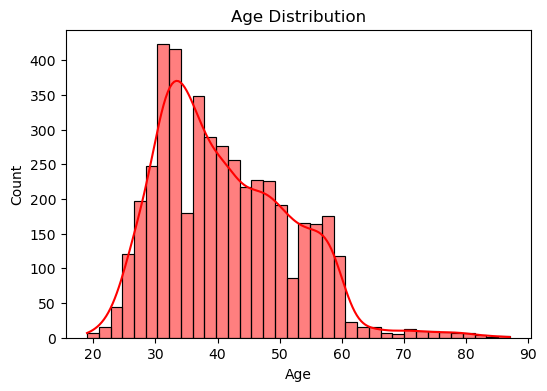

In [33]:
#Show Age of subscribers
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True, color='Red')
plt.title('Age Distribution')
plt.show()

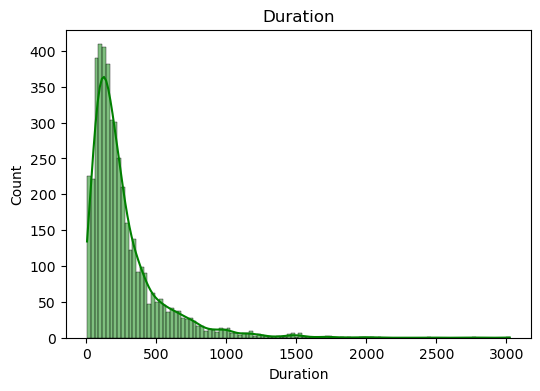

In [36]:
# Showing Duration of subscribe
plt.figure(figsize=(6, 4))
sns.histplot(df['Duration'], kde=True, color='green')
plt.title('Duration')
plt.show()

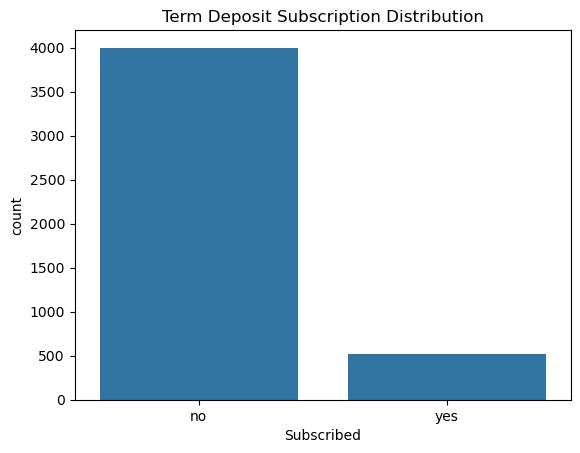

In [35]:
#Checking target distribution:
sns.countplot(x='Subscribed', data=df)
plt.title("Term Deposit Subscription Distribution")
plt.show()

# 5 preprocessing

In [76]:
#Encode Categorical Features
label_encoder = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_encoder.fit_transform(df[col])

# 6. Split Features and Target

In [41]:
X = df.drop('Subscribed', axis=1)
y = df['Subscribed']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train Models

In [109]:
log_model = LogisticRegression(
    solver='liblinear',
    max_iter=1000
)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# 8. Model Evaluation

# Confusion Matrix

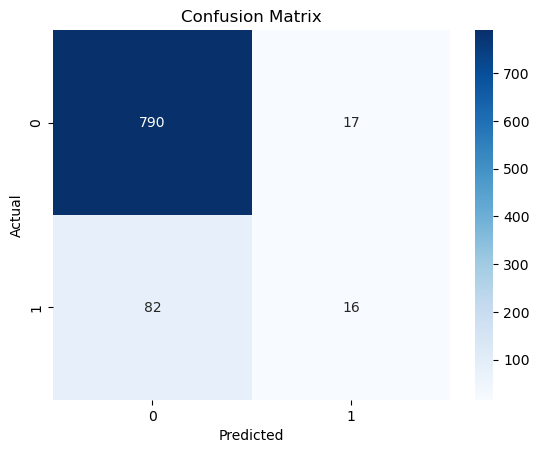

In [110]:
log_pred = log_model.predict(X_test)
cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# F1 Score

In [111]:
print("F1 Score:", f1_score(y_test, log_pred))

F1 Score: 0.24427480916030533


# Classification Report

In [112]:
print(classification_report(y_test, log_pred, target_names=['did not subscribe (0)', 'Subscribe (1)']))

                       precision    recall  f1-score   support

did not subscribe (0)       0.91      0.98      0.94       807
        Subscribe (1)       0.48      0.16      0.24        98

             accuracy                           0.89       905
            macro avg       0.70      0.57      0.59       905
         weighted avg       0.86      0.89      0.87       905



# ROC Curve

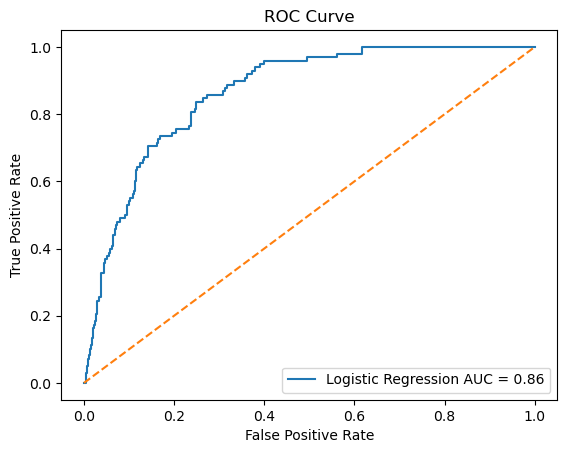

In [53]:
y_prob = log_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label="Logistic Regression AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 9 SHAP

In [105]:
sample = X_test.iloc[0:5]

Explanation for prediction: 1


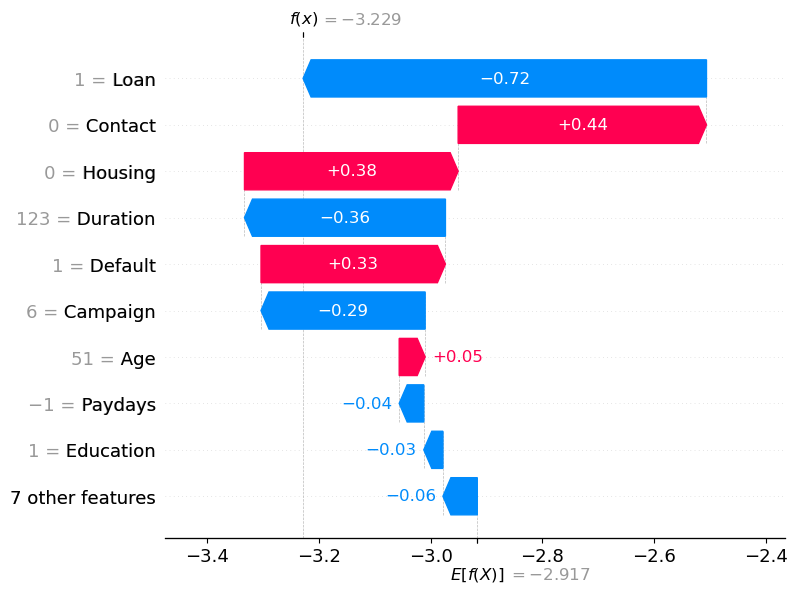

Explanation for prediction: 2


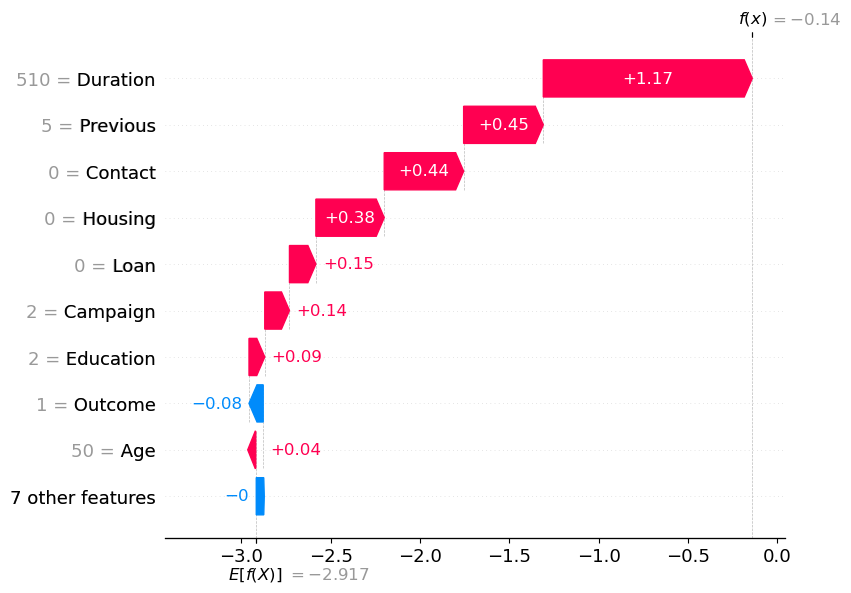

Explanation for prediction: 3


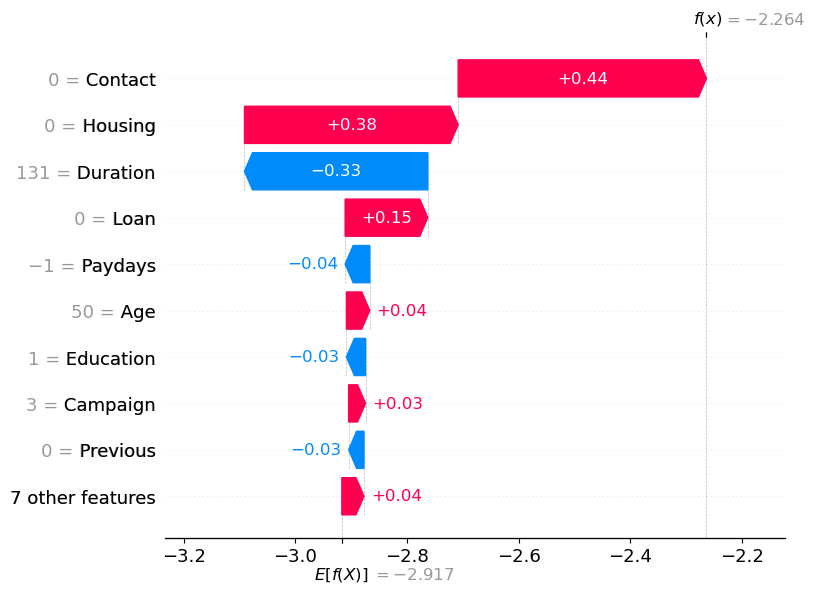

Explanation for prediction: 4


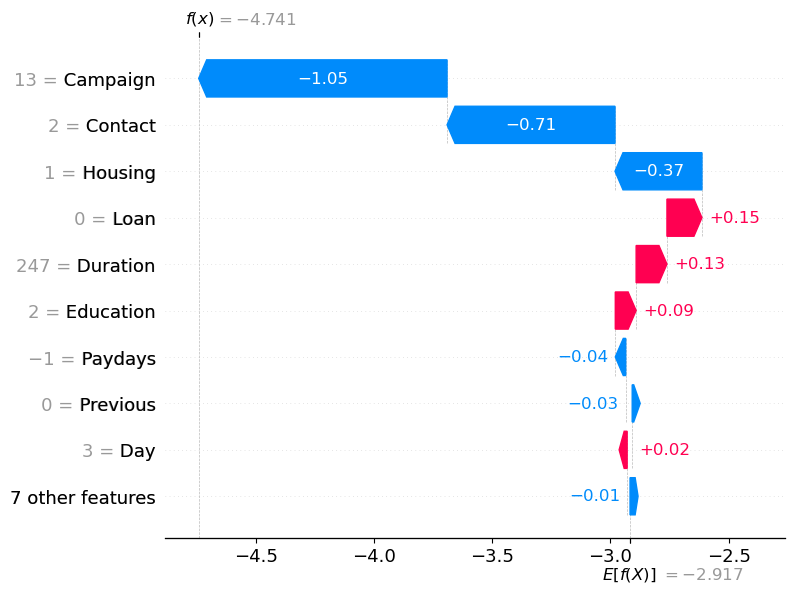

Explanation for prediction: 5


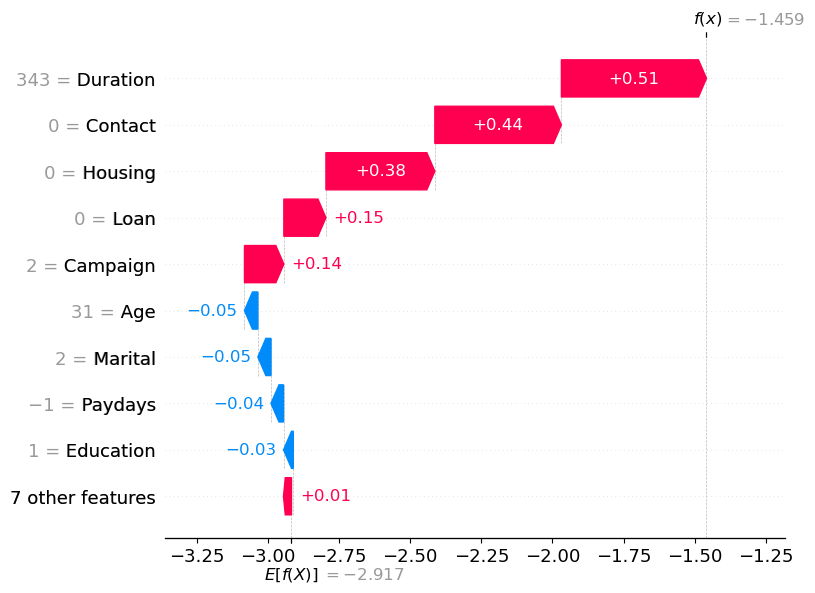

In [106]:
for i in range(5):
    print("Explanation for prediction:", i+1)
    shap.plots.waterfall(sample_shap_values[i])